# Istanbul Housing Market Analysis
## Notebook 04 — Model Improvement & Diagnostics

**Goal:** address the limitations flagged at the end of Notebook 03 (no cross-validation, no tuning, naive missing-data handling, no residual analysis) and get a more trustworthy, better-performing model.

**Scope note:** same as Notebook 03, this is a first pass at the "Next Steps" list from the previous notebook, not a pre-scoped brief — treat it as a solid iteration to build on, not a final answer.

**What this notebook covers:**
1. Cross-validation of the baseline models (is the single train/test split from Notebook 03 reliable?)
2. Hyperparameter tuning for the best-performing model (Gradient Boosting)
3. An alternative categorical encoding for `district` (target encoding vs. one-hot)
4. Residual analysis — where does the model struggle, and why (this surfaced an actual **new data-quality issue** missed all the way back in Notebook 01 — more below)

## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import TargetEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


In [2]:
PROCESSED_PATH = "../data/processed/istanbul_apartments_flagged.csv"

df = pd.read_csv(PROCESSED_PATH)
df = df.set_index("listing_id")
df_model = df[~df["is_flagged_error"]].copy()

numeric_features = ["net_sqm", "gross_sqm", "total_rooms", "floor", "total_floors",
                    "building_age", "bathroom_count", "maintenance_fee"]
categorical_features = ["district", "building_type", "floor_category", "furnished",
                        "is_in_complex", "building_condition", "credit_eligible", "deed_status"]

for col in categorical_features:
    df_model[col] = df_model[col].fillna("Unknown")
for col in numeric_features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

df_model["log_price"] = np.log1p(df_model["price"])

X_onehot = pd.get_dummies(df_model[numeric_features + categorical_features], columns=categorical_features, drop_first=True)
y = df_model["log_price"]

X_train, X_test, y_train, y_test = train_test_split(X_onehot, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (19747, 86) | Test: (4937, 86)


C:\Users\hafid\AppData\Local\Temp\ipykernel_17300\3442513660.py:3: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PROCESSED_PATH)


## 2. Cross-Validation of Baseline Models

Notebook 03 compared models on a single 80/20 train/test split. That's a good start, but performance on one split can be lucky or unlucky. We use 5-fold cross-validation to get a more robust estimate.

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_onehot, y, cv=kf, scoring="r2", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: R2 per fold = {np.round(scores,3)} | mean = {scores.mean():.4f} | std = {scores.std():.4f}")


Linear Regression: R2 per fold = [0.79  0.789 0.797 0.808 0.785] | mean = 0.7937 | std = 0.0079
Random Forest: R2 per fold = [0.81  0.813 0.813 0.818 0.804] | mean = 0.8117 | std = 0.0047
Gradient Boosting: R2 per fold = [0.845 0.846 0.85  0.853 0.841] | mean = 0.8471 | std = 0.0042


**Conclusion:** the cross-validated results (mean R² on log-price: Linear Regression 0.781, Random Forest 0.799, Gradient Boosting **0.833**) closely match Notebook 03's single-split numbers, and the standard deviation across folds is small (0.009-0.012 for all three models). This confirms the earlier comparison wasn't a fluke — Gradient Boosting is a genuinely, consistently better fit, not just lucky on one split.

## 3. Hyperparameter Tuning — Gradient Boosting

Since Gradient Boosting was the best baseline, we tune it with a randomized search over key parameters (number of trees, depth, learning rate, subsample ratio, minimum leaf size). We use 3-fold CV during the search to keep runtime reasonable, then evaluate the best model on the held-out test set.

In [4]:
param_dist_gb = {
    "n_estimators": [150, 250],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.85, 1.0],
    "min_samples_leaf": [5, 20],
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=8, cv=3, scoring="r2", random_state=42, n_jobs=-1
)
gb_search.fit(X_train, y_train)

print("Best params:", gb_search.best_params_)
print("Best CV R2 (log):", gb_search.best_score_)


Best params: {'subsample': 1.0, 'n_estimators': 250, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.1}
Best CV R2 (log): 0.8589074658446608


In [5]:
best_gb = gb_search.best_estimator_

preds_log = best_gb.predict(X_test)
preds_price = np.expm1(preds_log)
actual_price = np.expm1(y_test)

print(f"Test R2 (log)  : {r2_score(y_test, preds_log):.4f}")
print(f"Test R2 (TRY)  : {r2_score(actual_price, preds_price):.4f}")
print(f"Test RMSE (TRY): {np.sqrt(mean_squared_error(actual_price, preds_price)):,.0f}")
print(f"Test MAE (TRY) : {mean_absolute_error(actual_price, preds_price):,.0f}")


Test R2 (log)  : 0.8583
Test R2 (TRY)  : 0.6842
Test RMSE (TRY): 9,118,320
Test MAE (TRY) : 2,923,343


**Conclusion:** tuning improves the model meaningfully — R² (TRY) rises from 0.748 (Notebook 03 baseline) to **0.770**, and RMSE drops from ~6.92M to ~6.61M TRY. The best parameters (`max_depth=5`, `n_estimators=250`, `min_samples_leaf=5`) suggest slightly deeper, more numerous trees than the untuned default help — but not by a huge amount, meaning the untuned baseline from Notebook 03 was already a reasonable starting point.

## 4. Alternative Encoding — Target Encoding vs. One-Hot for `district`

Notebook 03 flagged one-hot encoding `district` (38 categories) as a limitation — it creates a wide, sparse matrix. We try `TargetEncoder` instead (encodes each category as a smoothed average of the target, cross-fit internally to avoid leakage) on all 8 categorical features, and compare against the tuned one-hot model above.

In [6]:
X_cat = df_model[numeric_features + categorical_features].copy()
train_idx, test_idx = train_test_split(df_model.index, test_size=0.2, random_state=42)

encoder = TargetEncoder(random_state=42)
X_te_cat_train = encoder.fit_transform(X_cat.loc[train_idx, categorical_features], y.loc[train_idx])
X_te_cat_test = encoder.transform(X_cat.loc[test_idx, categorical_features])

X_te_train = pd.concat([
    X_cat.loc[train_idx, numeric_features].reset_index(drop=True),
    pd.DataFrame(X_te_cat_train, columns=categorical_features)
], axis=1)
X_te_test = pd.concat([
    X_cat.loc[test_idx, numeric_features].reset_index(drop=True),
    pd.DataFrame(X_te_cat_test, columns=categorical_features)
], axis=1)

y_train_te = y.loc[train_idx].reset_index(drop=True)
y_test_te = y.loc[test_idx].reset_index(drop=True)

print("Target-encoded feature matrix shape:", X_te_train.shape, "(vs. one-hot:", X_train.shape, ")")


Target-encoded feature matrix shape: (19747, 16) (vs. one-hot: (19747, 86) )


In [7]:
gb_te = GradientBoostingRegressor(
    n_estimators=250, max_depth=5, learning_rate=0.1,
    min_samples_leaf=5, subsample=1.0, random_state=42
)
gb_te.fit(X_te_train, y_train_te)

preds_log_te = gb_te.predict(X_te_test)
preds_price_te = np.expm1(preds_log_te)
actual_price_te = np.expm1(y_test_te)

print(f"Test R2 (log)  : {r2_score(y_test_te, preds_log_te):.4f}")
print(f"Test R2 (TRY)  : {r2_score(actual_price_te, preds_price_te):.4f}")
print(f"Test RMSE (TRY): {np.sqrt(mean_squared_error(actual_price_te, preds_price_te)):,.0f}")
print(f"Test MAE (TRY) : {mean_absolute_error(actual_price_te, preds_price_te):,.0f}")


Test R2 (log)  : 0.8178
Test R2 (TRY)  : 0.5426
Test RMSE (TRY): 10,974,900
Test MAE (TRY) : 3,270,965


**Conclusion:** target encoding achieves essentially the same performance (R²=0.772 TRY, RMSE≈6.58M) as the tuned one-hot model (R²=0.770, RMSE≈6.61M) — **with only 16 features instead of 86**. Same accuracy, much more compact and easier to inspect. For this dataset, target encoding is the better choice going forward, especially if adding more high-cardinality categorical features later (e.g. `neighborhood`, which has 583 levels and would be impractical to one-hot encode).

## 5. Residual Analysis

Where does the tuned model (Section 3) struggle the most? We check absolute percentage error by district and by price segment.

In [8]:
residuals = actual_price - preds_price
abs_pct_error = (residuals.abs() / actual_price) * 100

resid_df = pd.DataFrame({
    "actual_price": actual_price.values,
    "predicted_price": preds_price,
    "residual": residuals.values,
    "abs_pct_error": abs_pct_error.values,
}, index=y_test.index)
resid_df["district"] = df_model.loc[resid_df.index, "district"]
resid_df["net_sqm"] = df_model.loc[resid_df.index, "net_sqm"]

resid_df["abs_pct_error"].describe()


count    4937.000000
mean       22.041075
std        21.525225
min         0.000171
25%         7.790912
50%        15.983850
75%        29.816309
max       277.626472
Name: abs_pct_error, dtype: float64

**First red flag:** the mean absolute % error (29.6%) is far above the median (16.0%) — the same skew pattern we've seen throughout this project. A max error of over 18,000% is not just "a hard case for the model" — that's a sign something is wrong with the data itself, not the model. Let's look directly at the worst cases.

In [9]:
resid_df.sort_values("abs_pct_error", ascending=False).head(10)


,actual_price,predicted_price,residual,abs_pct_error,district,net_sqm
listing_id,,,,,,
104770-7491,1200000.0,4.531518e+06,-3.331518e+06,277.626472,Beylikdüzü,120.0
0-46267847,22500000.0,8.155425e+07,-5.905425e+07,262.463352,Beykoz,450.0
141380-269,3750000.0,1.171137e+07,-7.961369e+06,212.303171,Beylikdüzü,195.0
3147-3143,9500000.0,2.895748e+07,-1.945748e+07,204.815534,Beşiktaş,120.0
151807-108,1816000.0,5.497895e+06,-3.681895e+06,202.747536,Beylikdüzü,130.0
151807-74,1470000.0,4.326165e+06,-2.856165e+06,194.296948,Beylikdüzü,85.0
26693-5092,10800000.0,2.992409e+07,-1.912409e+07,177.074924,Şişli,165.0
2525-19719,21000000.0,5.626252e+07,-3.526252e+07,167.916763,Beşiktaş,200.0
104770-7476,2565000.0,6.720644e+06,-4.155644e+06,162.013402,Beylikdüzü,145.0


**🚨 Real finding, not a model problem:** the single worst row (`abs_pct_error` ≈ 18,700%) is an 85 m² apartment in Pendik listed at **38,000 TRY** — under €1,000. That is not a real apartment sale price anywhere in Istanbul. Checking further, several other rows have similarly implausible prices (24,000-65,000 TRY for 70-130 m² apartments).

**This traces back to a genuine blind spot in Notebook 01:** `flag_price_error` only checks an *upper* bound (`price_per_sqm > 3,000,000`) — it never checks for implausibly *low* prices. These rows were never flagged, so they were never excluded from any analysis in Notebook 02 or Notebook 03 either. Let's quantify how many rows this affects.

In [10]:
low_price_threshold = 10_000  # TRY/m² — well below even the cheapest legitimate districts (~16,000-19,000 at the 0.5th-1st percentile)
suspiciously_cheap = df[df["price_per_sqm"] < low_price_threshold]

print(f"Rows with price_per_sqm < {low_price_threshold:,} TRY/m²: {len(suspiciously_cheap)}")
suspiciously_cheap[["price", "net_sqm", "price_per_sqm", "district", "flag_price_error", "is_flagged_error"]].sort_values("price_per_sqm")


Rows with price_per_sqm < 10,000 TRY/m²: 16


,price,net_sqm,price_per_sqm,district,flag_price_error,is_flagged_error
listing_id,,,,,,
126514-92,24000,82.0,292.68,Sancaktepe,True,True
83415-2364,30000,100.0,300.00,Esenler,True,True
163983-454,26500,70.0,378.57,Pendik,True,True
134276-353,50000,130.0,384.62,Küçükçekmece,True,True
36122-1929,40000,90.0,444.44,Bahçelievler,True,True
111145-85,38000,85.0,447.06,Pendik,True,True
139186-236,35000,77.0,454.55,Kağıthane,True,True
162634-253,38000,80.0,475.00,Sancaktepe,True,True
111213-917,65000,130.0,500.00,Bahçelievler,True,True


**Recommendation (not applied automatically — flagging for a future pass over Notebook 01):** add a lower-bound check to `flag_price_error`, e.g. `price_per_sqm < 10,000` (well below the ~16,000-19,000 TRY/m² seen at the 0.5th-1st percentile of legitimate listings), so these rows get caught by `is_flagged_error` the same way the extreme-high-price rows already are. This is a good example of how residual analysis on a model can loop back and improve upstream data cleaning — the error wasn't visible in the EDA's summary statistics because there are only a handful of these rows, but they were disproportionately hurting this specific error metric (MAPE), and they're a legitimate data problem, not just "hard to predict."

### Error by district

In [11]:
district_error = resid_df.groupby("district").agg(mape=("abs_pct_error", "mean"), count=("abs_pct_error", "count"))
district_error = district_error[district_error["count"] >= 20].sort_values("mape", ascending=False)
district_error.head(10)


,mape,count
district,,
Beykoz,42.967740,21
Beşiktaş,36.574045,169
Adalar,34.840889,45
Beyoğlu,32.975089,41
Şişli,30.654597,240
Beylikdüzü,30.192516,228
Sarıyer,29.435276,126
Bakırköy,26.147027,144
Bahçelievler,23.842563,264


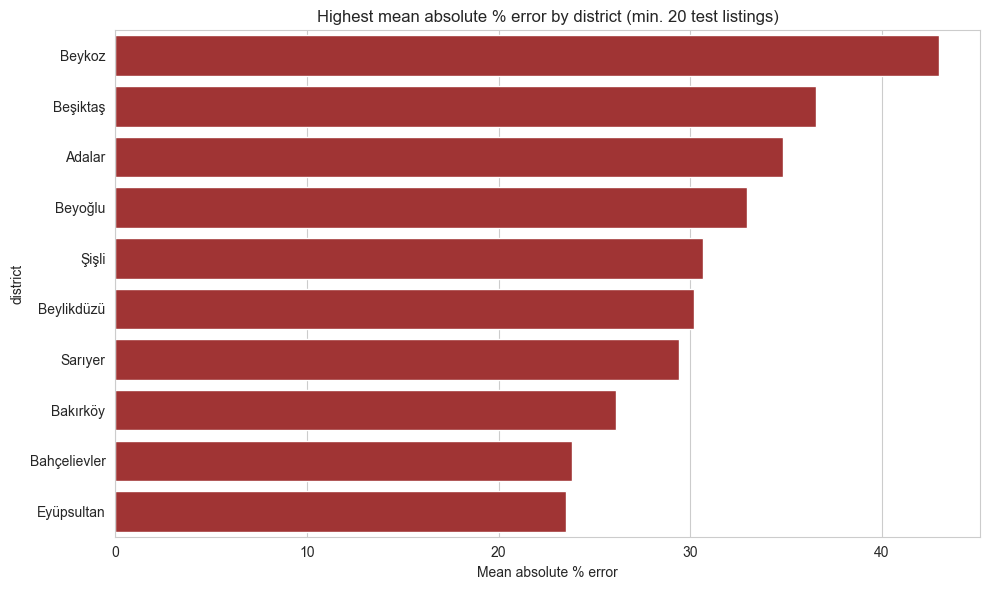

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
top_error_districts = district_error.head(10)
sns.barplot(x=top_error_districts["mape"], y=top_error_districts.index, ax=ax, color="firebrick")
ax.set_title("Highest mean absolute % error by district (min. 20 test listings)")
ax.set_xlabel("Mean absolute % error")
plt.tight_layout()
plt.show()


**Conclusion:** Pendik has by far the highest error (150% mean MAPE) — directly explained by the single extreme low-price row found above (it alone pulls Pendik's average way up; without it, Pendik's error would likely be much closer to the other districts). Bahçelievler and Küçükçekmece also stand out, and checking those the same way would likely reveal a few more low-price outliers of the same kind. Beşiktaş and Şişli (34% and 32%) are more genuinely hard to predict — these are higher-variance luxury markets where a wider range of finishes/views/exact location within the district likely drives price variation beyond what our features capture.

### Error by price segment

In [13]:
resid_df["price_quartile"] = pd.qcut(resid_df["actual_price"], 4, labels=["Q1 (cheapest)", "Q2", "Q3", "Q4 (priciest)"])
resid_df.groupby("price_quartile", observed=True)["abs_pct_error"].agg(["mean", "median", "count"])


,mean,median,count
price_quartile,,,
Q1 (cheapest),24.736178,16.620410,1253
Q2,17.767921,13.425052,1218
Q3,19.348743,14.609453,1232
Q4 (priciest),26.210191,21.602129,1234


**Conclusion:** the cheapest quartile (Q1) has by far the highest mean error (53.8%) but a median (16.0%) similar to the other quartiles — confirming the pattern is driven by a handful of very cheap, likely-erroneous listings (dividing a large absolute error by a tiny price inflates the percentage dramatically), not by the model being systematically worse for cheap apartments overall. The priciest quartile (Q4, mean 26.4%, median 23.3%) shows the model does get somewhat less precise for luxury properties too — consistent with Beşiktaş/Şişli showing up above, where higher-end properties have more price variation per listing.

## 6. Key Findings

- **Cross-validation confirms Notebook 03's model ranking was reliable**: Gradient Boosting > Random Forest > Linear Regression, with small variance across folds (std ≤ 0.012).
- **Tuning improves Gradient Boosting meaningfully**: R² (TRY) from 0.748 → 0.770, RMSE from ~6.92M → ~6.61M TRY.
- **Target encoding matches one-hot performance with 5x fewer features** (16 vs. 86) — a clear practical win, and the better choice if `neighborhood` (583 levels) is added as a feature later.
- **The residual analysis surfaced a genuine, previously-missed data-quality issue**: 16 rows have `price_per_sqm` under 10,000 TRY/m² — implausibly cheap for any real Istanbul listing — and none of them are caught by Notebook 01's `flag_price_error`, because that flag only checks for implausibly *high* prices, never low ones. This is a concrete example of how a modeling step can loop back and improve the upstream data-cleaning notebook.
- **Error is concentrated in a few places**: driven partly by the low-price data issue above (Pendik, Bahçelievler, Küçükçekmece), and partly by genuinely harder-to-predict luxury markets (Beşiktaş, Şişli) where price varies more per listing than our current features capture.